In [4]:
# import useful libraries
import os #fornisce funzioni per interagire con il sistema operativo
import glob #trova file con pattern specifici, tipo cerca tutti i file .jpg
import numpy as np #per il calcolo numerico
import pandas as pd #per manipolare dati tabulari tipo exel
import matplotlib.pyplot as plt #per creare e grafici e visualizzazioni di dati
import seaborn as sns #per visualizzazioni statistiche più intuitive
import scipy.io as sio # useful because ground truth labels are uploaded as .mat files
import cv2 # per cariche e processare le immagini
import matplotlib.patches as patches #per disegnare forme sopra le immagini
data_dir = 'data/PanNuke/train'
# viene creata una variabile chiamata data_dir che contiene il nome di una cartella
os.listdir(data_dir)
# Restituisce una lista di stringhe, ognuna corrispondente a un elemento nella cartella lizard
# elenca tutti i file e sottocartelle 

['images', 'masks']

In [5]:
# 1. Definiamo il percorso base (come nel tuo esempio)
data_dir = 'data/PanNuke/' 

# 2. Raccogliamo tutti i percorsi delle immagini (image_paths)
# Usiamo glob.glob e os.path.join proprio come nel codice Lizard
all_images = sorted(glob.glob(os.path.join(data_dir, "train", "images", "*.png*")) + 
                   glob.glob(os.path.join(data_dir, "validate", "images", "*.png*")))

# 3. Raccogliamo tutti i percorsi delle maschere (mask_paths)
# Seguiamo la stessa identica logica per le labels/masks
all_masks = sorted(glob.glob(os.path.join(data_dir, "train", "masks", "*.png")) + 
                   glob.glob(os.path.join(data_dir, "validate", "masks", "*.png")))
# Verifica dei risultati
print(f"Numero totale di immagini trovate: {len(all_images)}")
print(f"Numero totale di maschere trovate: {len(all_masks)}") 

Numero totale di immagini trovate: 7901
Numero totale di maschere trovate: 7901


In [6]:
nuclei_counts=[]

#loop su ogni maschera
for mask_path in all_masks:
    mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)  # carica in scala di grigi

    # conta i nuclei
    num_labels, _ = cv2.connectedComponents(mask)
    # Il numero di nuclei è num_labels meno 1 (lo sfondo)
    n_nuclei = num_labels - 1
    
    # 3. Aggiungiamo il numero alla lista
    nuclei_counts.append(n_nuclei)
# 3. Risultati finali
totale_nuclei_dataset = sum(nuclei_counts)
media_nuclei_dataset = np.mean(nuclei_counts) #funzione della libreria NumPy che serve a calcolare la media aritmetica dei numeri contenuti in una lista o in un array
print(f"Nuclei totali nel dataset:", totale_nuclei_dataset)
print(f"Media di nuclei per immagine: {media_nuclei_dataset:.2f}") 


Nuclei totali nel dataset: 160803
Media di nuclei per immagine: 20.35


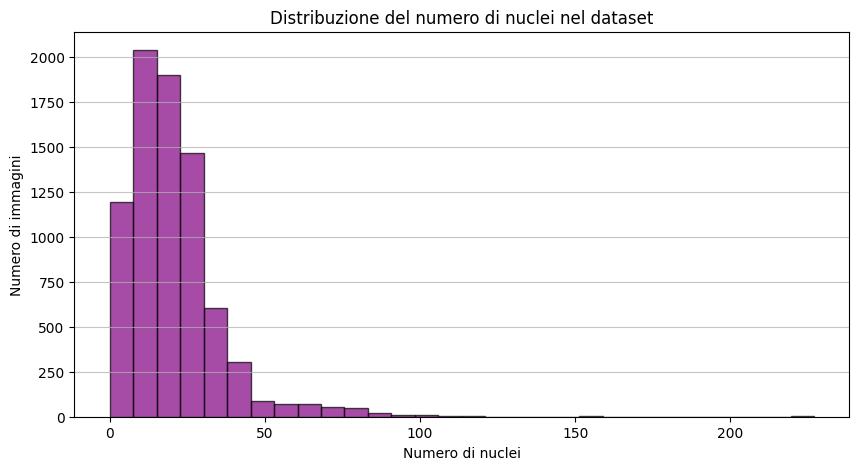

In [7]:
#istogramma densità - train e validate uniti
plt.figure(figsize=(10, 5))
plt.hist(nuclei_counts, bins=30, color='purple', edgecolor='black', alpha=0.7)
plt.title('Distribuzione del numero di nuclei nel dataset')
plt.xlabel('Numero di nuclei')
plt.ylabel('Numero di immagini')
plt.grid(axis='y', alpha=0.75)
plt.show()  

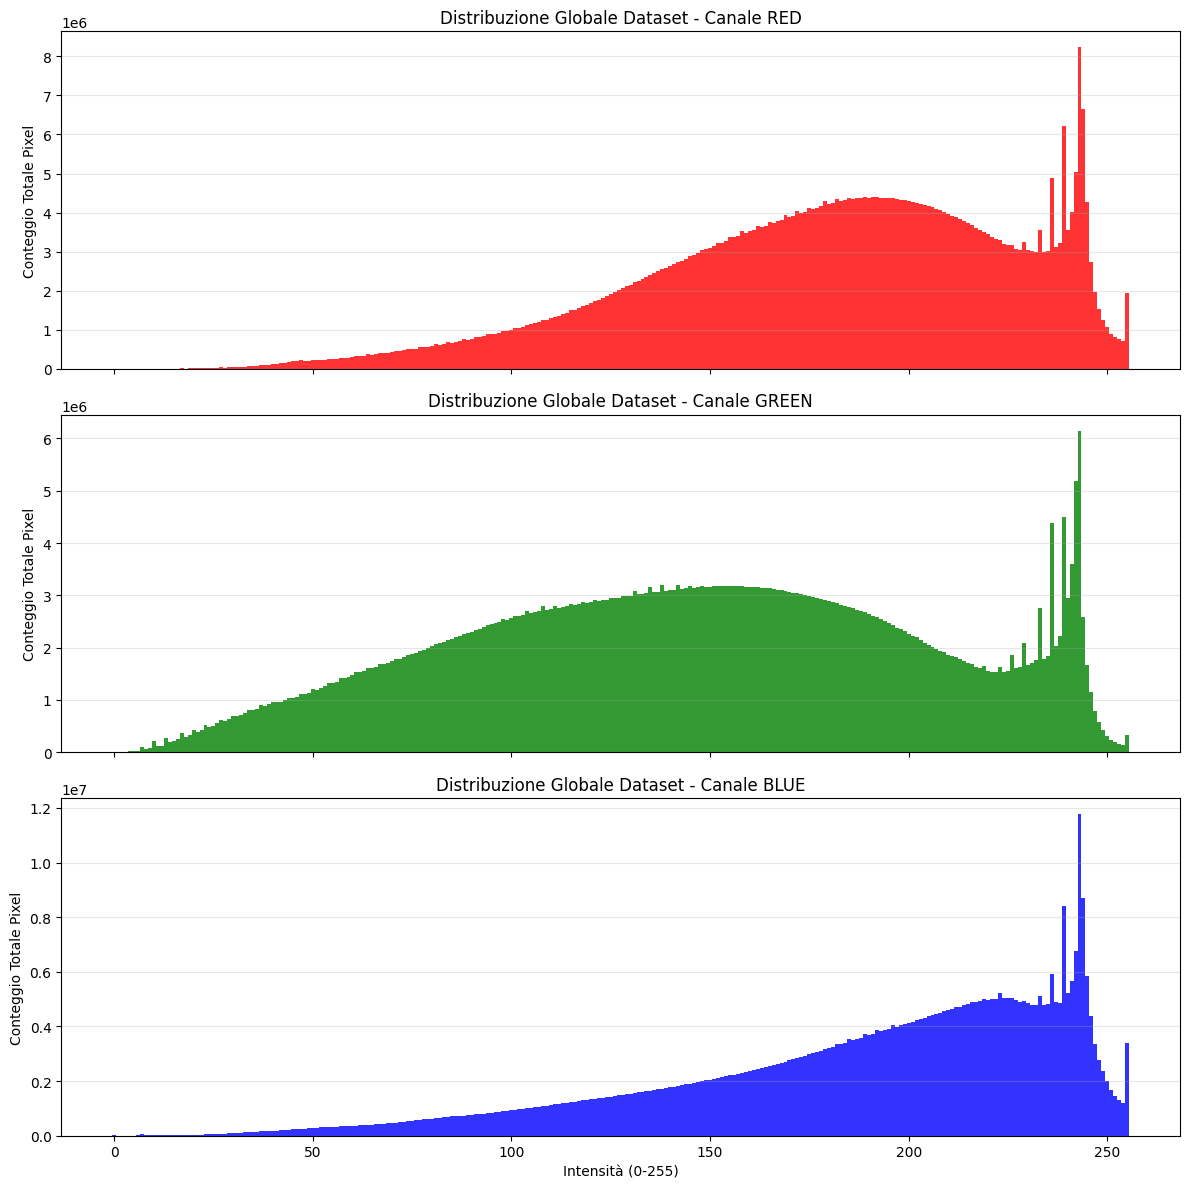

In [8]:
# 1. Inizializziamo tre vettori di 256 zeri (uno per canale)
# Qui accumuleremo i conteggi di tutti i pixel di un certo canale del dataset
global_hist_r = np.zeros(256) 
global_hist_g = np.zeros(256)
global_hist_b = np.zeros(256)
for i in range(len(all_images)): #Crea una sequenza di numeri che parte da 0 e arriva a (len(image_paths))-1 -> uesti numeri serviranno come "indice" (i) per andare a pescare l'immagine corretta nella lista 
                                  #ogni volta che il ciclo ricomincia
    # Carichiamo immagine e maschera
    img_bgr = cv2.imread(all_images[i])
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    
    mask_img = cv2.imread(all_images[i], cv2.IMREAD_GRAYSCALE)
    mask_binaria = (mask_img > 0).astype(np.uint8) * 255
    if np.any(mask_binaria): #stiamo chiedendo a Python di controllare la maschera dell'immagine corrente prima di fare i calcoli  -> controlliamo se nell'immagine c'è almeno un nucleo
                     #Se la maschera contiene almeno un nucleo: np.any vede dei valori diversi da zero (i pixel dei nuclei), restituisce True e il codice calcola l'istogramma
                     #e la maschera è completamente nera (no nuclei) np.any restituisce False. Il codice salta le operazioni di calcolo e passa all'immagine successiva
        # Calcoliamo l'istogramma dell'immagine corrente e lo SOMMIAMO a quello globale -> calcHist conta quanti pixel ci sono per ogni livello di intensità (da 0 a 255).
        global_hist_r += cv2.calcHist([img_rgb], [0], mask_binaria, [256], [0, 256]).flatten() # [img_rgb]: L'immagine a colori,[0] indica il codice del canale (0 per il rosso), mask dice di contare solo i pixel dove la maschera è bianca [256], [0, 256]: Crea 256 "cassetti" per i valori da 0 a 25
        global_hist_g += cv2.calcHist([img_rgb], [1], mask_binaria, [256], [0, 256]).flatten()
        global_hist_b += cv2.calcHist([img_rgb], [2], mask_binaria, [256], [0, 256]).flatten()
        # 3. Visualizzazione della Distribuzione Globale
# Usiamo i subplots 
fig, axs = plt.subplots(3, 1, figsize=(12, 12), sharex=True)
colors = ('red', 'green', 'blue')
global_hists = (global_hist_r, global_hist_g, global_hist_b)
x_values = np.arange(256)

for i, col in enumerate(colors):
    # Appiattiamo
    y_values= global_hists[i]
    axs[i].bar(x_values, y_values, color=col, alpha=0.8, width=1.0)
    axs[i].set_title(f"Distribuzione Globale Dataset - Canale {col.upper()}")
    axs[i].set_ylabel("Conteggio Totale Pixel")
    axs[i].grid(axis='y', alpha=0.3)

plt.xlabel("Intensità (0-255)")
plt.tight_layout()
plt.show() 


In [9]:
# Creiamo l'asse delle intensità (i valori da 0 a 255)
x = np.arange(256)
# Liste per rendere il calcolo più pulito nel ciclo
global_hists = [global_hist_r, global_hist_g, global_hist_b]
channel_names = ["ROSSO", "VERDE", "BLU"] 
for i, hist in enumerate(global_hists):
    # 1. Assicuriamoci che l'istogramma sia piatto (1D)
    counts = hist
    # 2. Calcoliamo il numero totale di pixel analizzati per questo canale
    total_pixels = np.sum(counts)
    
    if total_pixels > 0:
        # 3. MEDIA PESATA: Somma di (intensità * conteggio) / totale pixel
        # Esempio: (0*10 + 1*5 + ... + 255*100) / totale
        mean_global = np.sum(x * counts) / total_pixels
        # 4. VARIANZA PESATA: Somma di (conteggio * (intensità - media)^2) / totale
        variance_global = np.sum(counts * (x - mean_global)**2) / total_pixels
        
        # 5. DEVIAZIONE STANDARD: Radice quadrata della varianza
        std_global = np.sqrt(variance_global)
        print(f"Canale {channel_names[i]}:")
        print(f"  > Media: {mean_global:.2f}")
        print(f"  > Dev. Std: {std_global:.2f}") 

Canale ROSSO:
  > Media: 179.72
  > Dev. Std: 45.56
Canale VERDE:
  > Media: 146.19
  > Dev. Std: 57.61
Canale BLU:
  > Media: 189.04
  > Dev. Std: 48.52


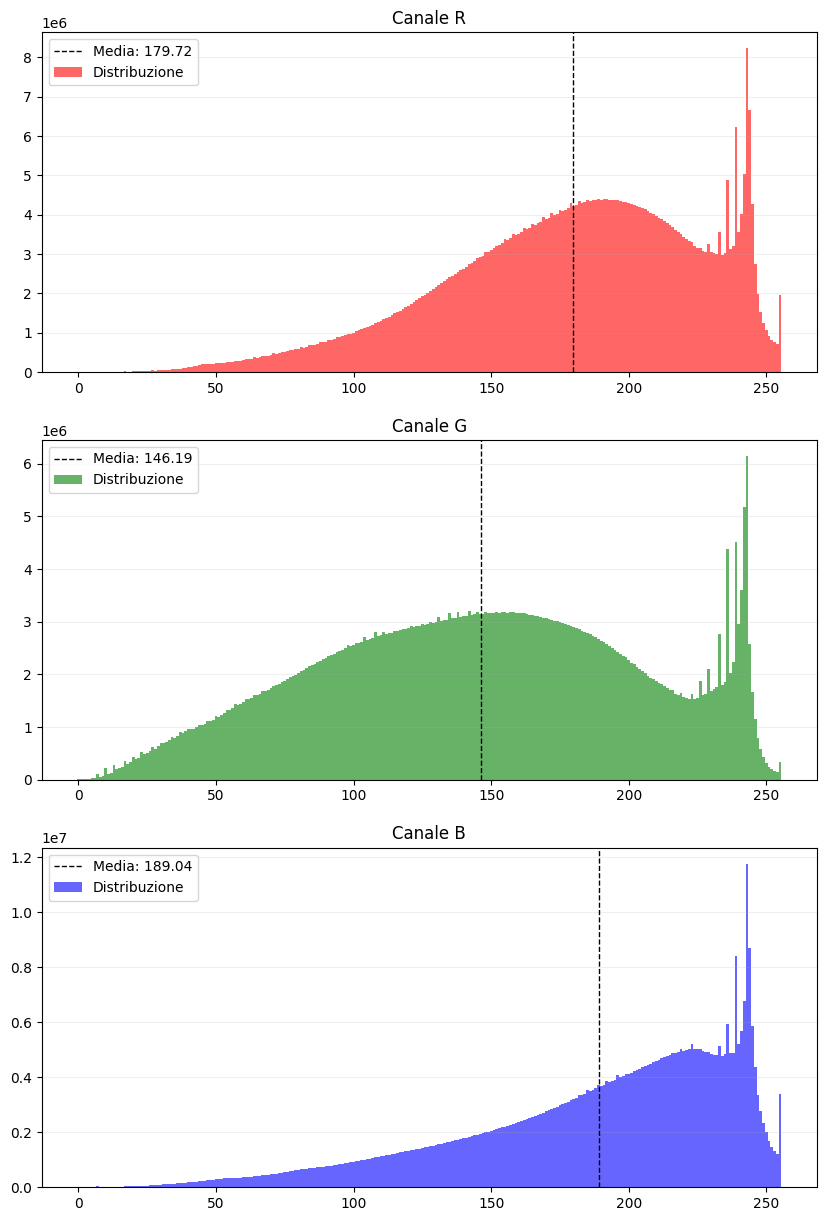

In [10]:
# Lista delle medie calcolate in precedenza
fig, axs = plt.subplots(3, 1, figsize=(10, 15))
global_means = [179.72, 146.19, 189.04] 
colors = ['r', 'g', 'b']

for i, col in enumerate(colors):
    y_values = global_hists[i]
    
    # 1. Disegniamo l'istogramma a barre
    axs[i].bar(x_values, y_values, color=col, alpha=0.6, width=1.0, label='Distribuzione')
    
    # 2. AGGIUNGIAMO LA BARRA DEL VALOR MEDIO
    mean_val = global_means[i]
    axs[i].axvline(mean_val, color='black', linestyle='--', linewidth=1, 
                   label=f'Media: {mean_val:.2f}') #axvline(mean_val, ...): Disegna una linea verticale fissa sul valore X della media   
    # 3. Abbellimenti
    axs[i].set_title(f"Canale {col.upper()}")
    axs[i].legend() # Necessario per mostrare l'etichetta della media
    axs[i].grid(axis='y', alpha=0.2)
plt.show() 

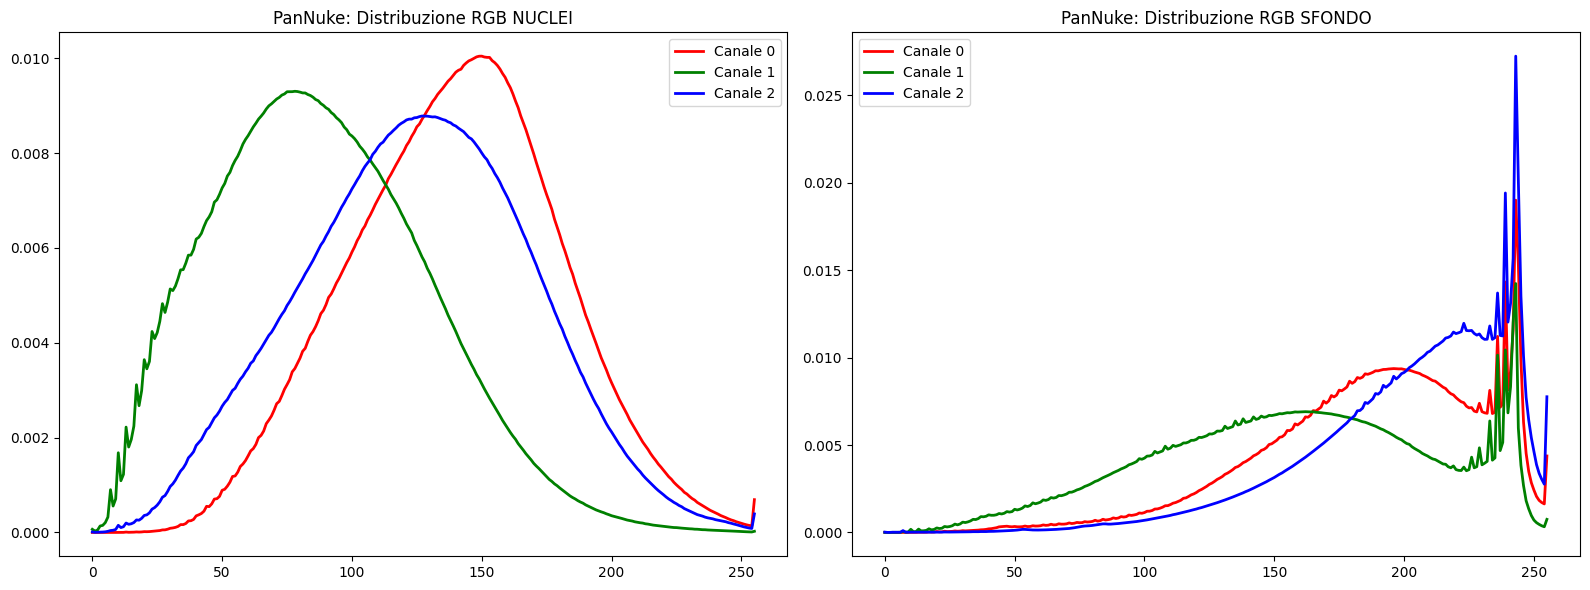

In [23]:
from PIL import Image
# Inizializziamo i contatori
# 1. INIZIALIZZAZIONE
hist_nuclei = np.zeros((256, 3)) 
hist_bg = np.zeros((256, 3))

for i in range(len(all_images)):
    # 1. Caricamento
    img = np.array(Image.open(all_images[i]).convert('RGB')) 
    mask = np.array(Image.open(all_masks[i])) 
    
    # 2. Logica Maschera
    is_nucleus = mask > 0
    is_bg = mask == 0
    
    # Controllo dimensioni maschera (se 3D la portiamo a 2D)
    if is_nucleus.ndim == 3:
        is_nucleus = is_nucleus[:, :, 0]
        is_bg = is_bg[:, :, 0]

    # 3. Ciclo Canali (ASSICURATI CHE SIA ALLINEATO QUI SOTTO)
    for ch in range(3):
        canale_corrente = img[:, :, ch]
        
        # Accumulo dati negli istogrammi globali
        hist_nuclei[:, ch] += np.histogram(canale_corrente[is_nucleus], bins=256, range=(0, 256))[0]
        hist_bg[:, ch] += np.histogram(canale_corrente[is_bg], bins=256, range=(0, 256))[0]

 #for i in range(len(all_images)):
    # CARICAMENTO PNG
    # Usiamo Image.open e convertiamo subito in array NumPy
    #img = np.array(Image.open(all_images[i]).convert('RGB')) 
    #mask = np.array(Image.open(all_masks[i]))

# --- PARTE 2: GRAFICO (Tutto a sinistra!) ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
colors = ['red', 'green', 'blue']

# Calcolo totali per normalizzare
total_n = hist_nuclei.sum(axis=0)[0] if hist_nuclei.sum() > 0 else 1
total_b = hist_bg.sum(axis=0)[0] if hist_bg.sum() > 0 else 1

for ch in range(3):
    ax1.plot(hist_nuclei[:, ch] / total_n, color=colors[ch], label=f'Canale {ch}', lw=2)
    ax2.plot(hist_bg[:, ch] / total_b, color=colors[ch], label=f'Canale {ch}', lw=2)

ax1.set_title("PanNuke: Distribuzione RGB NUCLEI")
ax2.set_title("PanNuke: Distribuzione RGB SFONDO")
ax1.legend()
ax2.legend()
plt.tight_layout()
plt.show() 

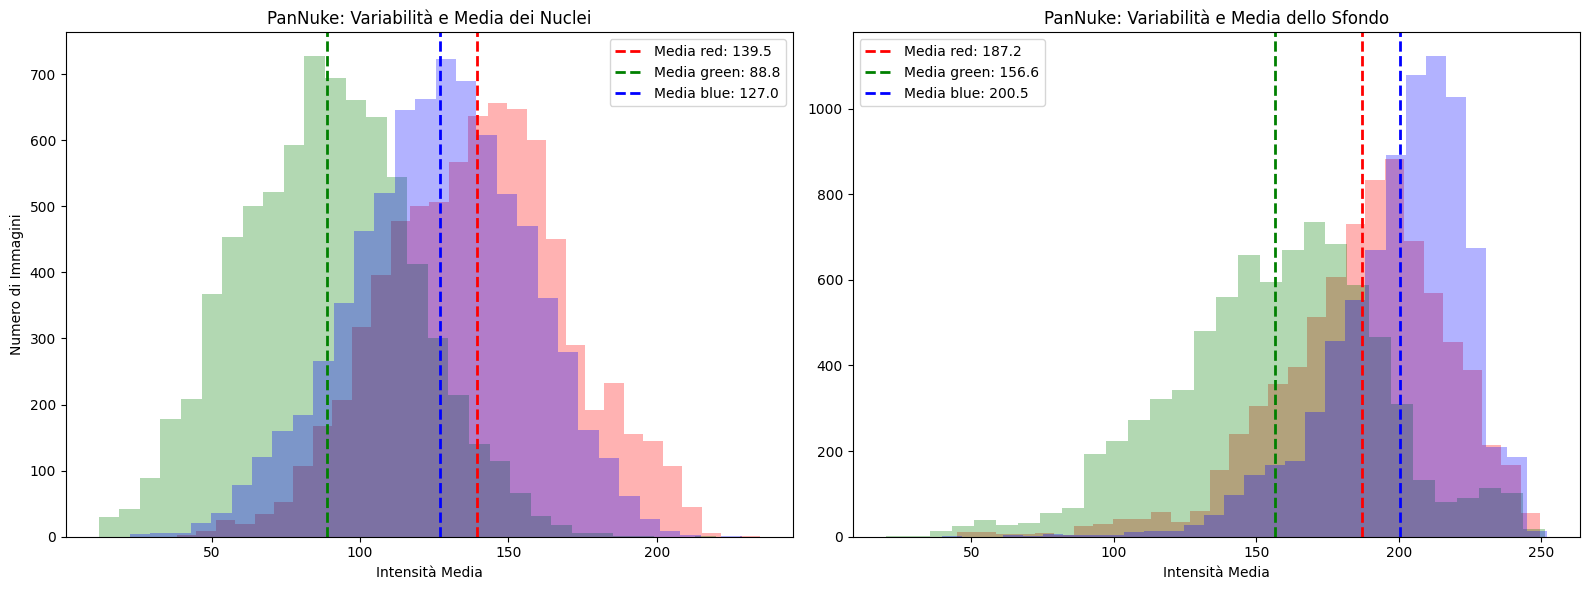

In [25]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import pandas as pd

# --- 1. INIZIALIZZAZIONE ---
# Liste per salvare la media di ogni singola immagine
means_nuclei = []
means_bg = []


# --- 2. CICLO DI CALCOLO ---
for i in range(len(all_images)):
    # Caricamento
    img = np.array(Image.open(all_images[i]).convert('RGB'))
    mask = np.array(Image.open(all_masks[i]))
    
    # Maschere
    is_nucleus = mask > 0
    is_bg = mask == 0
    
    # Se la maschera è 3D, la portiamo a 2D
    if is_nucleus.ndim == 3:
        is_nucleus = is_nucleus[:, :, 0]
        is_bg = is_bg[:, :, 0]
    
    # Calcoliamo la media RGB solo se ci sono pixel presenti
    # Usiamo np.nan se un'immagine non avesse nuclei (raro in PanNuke)
    if np.any(is_nucleus):
        m_n = img[is_nucleus].mean(axis=0) # Restituisce [R_mean, G_mean, B_mean]
        means_nuclei.append(m_n)
    
    if np.any(is_bg):
        m_b = img[is_bg].mean(axis=0)
        means_bg.append(m_b)


# Convertiamo in array numpy per facilitare il plotting
means_nuclei = np.array(means_nuclei)
means_bg = np.array(means_bg)

# --- 3. PLOT DEGLI ANDAMENTI (Distribuzione delle Medie) ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
colors = ['red', 'green', 'blue']
labels = ['Media Rosso', 'Media Verde', 'Media Blu']
for ch in range(3):
    # 1. Disegniamo l'andamento (istogramma) delle medie di tutte le immagini
    ax1.hist(means_nuclei[:, ch], bins=30, color=colors[ch], alpha=0.3)
    
    # 2. Calcoliamo la MEDIA GLOBALE di quel canale
    media_globale = np.mean(means_nuclei[:, ch])
    
    # 3. Disegniamo la "LINEA" che cercavi (verticale)
    ax1.axvline(media_globale, color=colors[ch], linestyle='--', lw=2, 
                label=f'Media {colors[ch]}: {media_globale:.1f}')

ax1.set_title("PanNuke: Variabilità e Media dei Nuclei")
ax1.set_xlabel("Intensità Media")
ax1.set_ylabel("Numero di Immagini")
ax1.legend()

# Ripetiamo per lo Sfondo
for ch in range(3):
    ax2.hist(means_bg[:, ch], bins=30, color=colors[ch], alpha=0.3)
    media_globale_bg = np.mean(means_bg[:, ch])
    ax2.axvline(media_globale_bg, color=colors[ch], linestyle='--', lw=2,
                label=f'Media {colors[ch]}: {media_globale_bg:.1f}')

ax2.set_title("PanNuke: Variabilità e Media dello Sfondo")
ax2.set_xlabel("Intensità Media")
ax2.legend()

plt.tight_layout()
plt.show() 